<a href="https://colab.research.google.com/github/Pavendhan-dev/Pluto_AI_Project/blob/main/EDA_%26_IR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exploratory Data Analysis & Insights Report**

## **Load & Inspect the Data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Project/netflix_titles[1].csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
print("Shape of Dataset:")
print(df.shape)

Shape of Dataset:
(8807, 12)


In [ ]:
print("Dataset Information:")
print(df.info())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [ ]:
print("Duplicate Values:")
print(df.duplicated().sum())

Duplicate Values:
0


###5-Line Summary


1. The dataset contains information about Movies and TV Shows available on Netflix.
2. It includes details such as title, director, cast, country, release year, rating, duration, and genre.
3. The dataset consists of thousands of records representing Netflix content from different countries and years.
4. Some columns contain missing values, especially director, cast, country, and date added information.
5. This dataset can be used to analyze content trends, popular genres, ratings, and Netflix's global content distribution.


## **Clean the Data**

In [ ]:
print("Missing Values Before Cleaning:")
print(df.isnull().sum())


df['director']=df['director'].fillna('Unknown')
df['cast']=df['cast'].fillna('Unknown')
df['country']=df['country'].fillna('Unknown')
df['rating']=df['rating'].fillna(df['rating'].mode()[0])



Missing Values Before Cleaning:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [ ]:
df.dropna(subset=['date_added'], inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')


In [ ]:
print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      88
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64


In [ ]:
print("Dataset Shape After Cleaning:")
print(df.shape)

Dataset Shape After Cleaning:
(8797, 12)


###Cleaning Decisions and Reasons
1. Missing values in the director column were replaced with "Unknown" because removing these rows would result in loss of useful content information.

2. Missing values in the cast column were replaced with "Unknown" for the same reason, ensuring that records remain available for analysis.

3. Missing values in the country column were filled with "Unknown" to retain records while clearly indicating unavailable information.

4. Missing values in the rating column were filled using the most frequent rating (mode) because ratings are important for content classification.

5. Rows with missing date_added values were removed since the date is essential for time-based analysis and cannot be reliably inferred.

6. The date_added column was converted to datetime format to enable date-related analysis and visualization.

7. Duplicate records were removed to prevent repeated entries from affecting analysis results.

8. No important columns were removed because all available features contribute useful information for exploratory data analysis.


## **Exploratory Data Analysis (EDA)**

1.How many Movies and TV Shows are available on Netflix?

In [ ]:
print("Movies and TV Shows:")
print(df['type'].value_counts())

Movies and TV Shows:
type
Movie      6131
TV Show    2666
Name: count, dtype: int64


2.Which are the Top 10 Countries with the most content?

In [ ]:
print("Top 10 Countries:")
print(df['country'].value_counts().head(10))

Top 10 Countries:
country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


3.What are the most common content ratings?

In [ ]:
print("Content Ratings:")
print(df['rating'].value_counts())

Content Ratings:
rating
TV-MA       3209
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


4.How has Netflix content changed over the years?

In [ ]:
print("Top Release Years:")
print(df.groupby('release_year')['show_id'].count().sort_values(ascending=False).head(10))

Top Release Years:
release_year
2018    1146
2017    1032
2019    1030
2020     953
2016     901
2021     592
2015     558
2014     352
2013     287
2012     236
Name: show_id, dtype: int64


5.What is the statistical summary of the release year?

In [ ]:
print("Release Year Statistics:")
print(df['release_year'].describe())

Release Year Statistics:
count    8797.000000
mean     2014.183472
std         8.822191
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64


## **Visualizations**

1.Bar Chart – Movies vs TV Shows

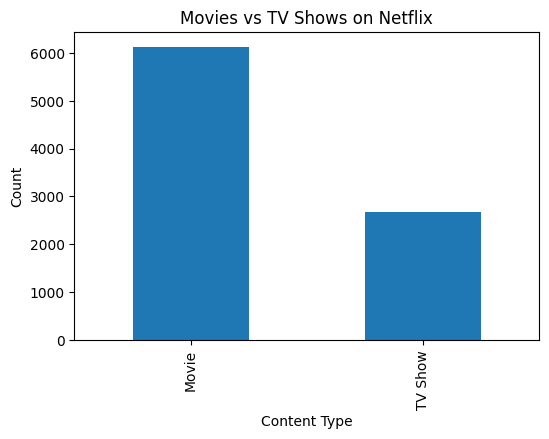

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

df['type'].value_counts().plot(kind='bar')

plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')

plt.show()

2.Line Chart – Content Released Over Years

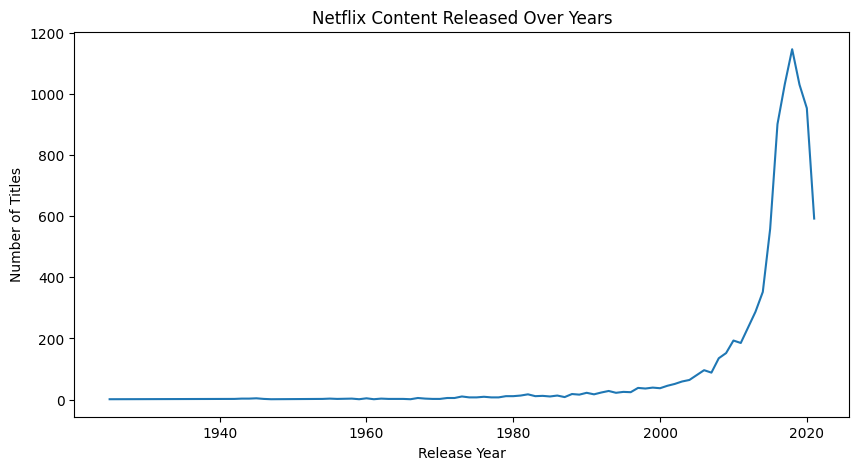

In [ ]:
year_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.plot(year_counts.index, year_counts.values)

plt.title('Netflix Content Released Over Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.show()

3.Histogram – Release Year Distribution

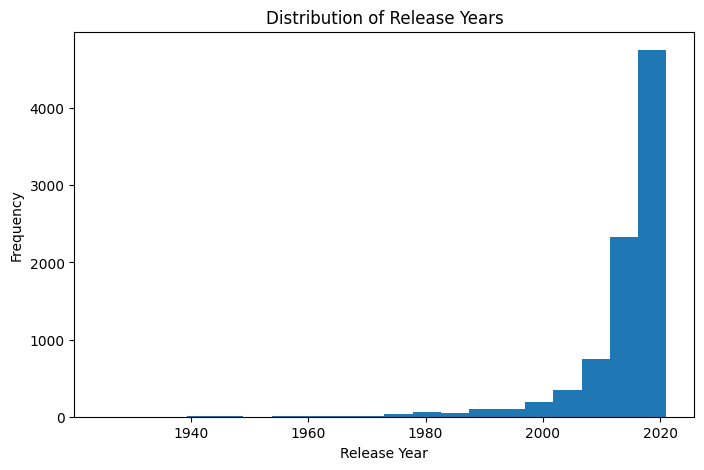

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['release_year'], bins=20)

plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Frequency')

plt.show()

4.Scatter Plot – Dataset Index vs Release Year

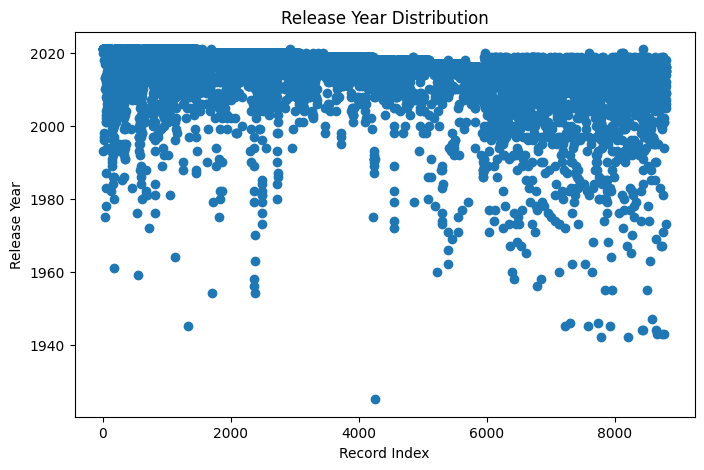

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df.index, df['release_year'])

plt.title('Release Year Distribution')
plt.xlabel('Record Index')
plt.ylabel('Release Year')

plt.show()

5.Pie Chart – Movies vs TV Shows Percentage

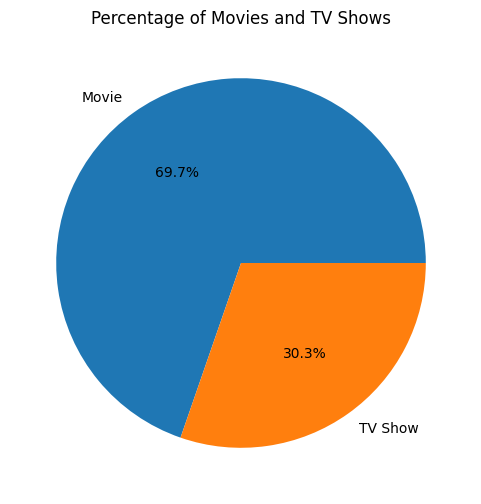

In [ ]:
plt.figure(figsize=(6,6))

df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Percentage of Movies and TV Shows')
plt.ylabel('')

plt.show()

6.Heatmap – Missing Values

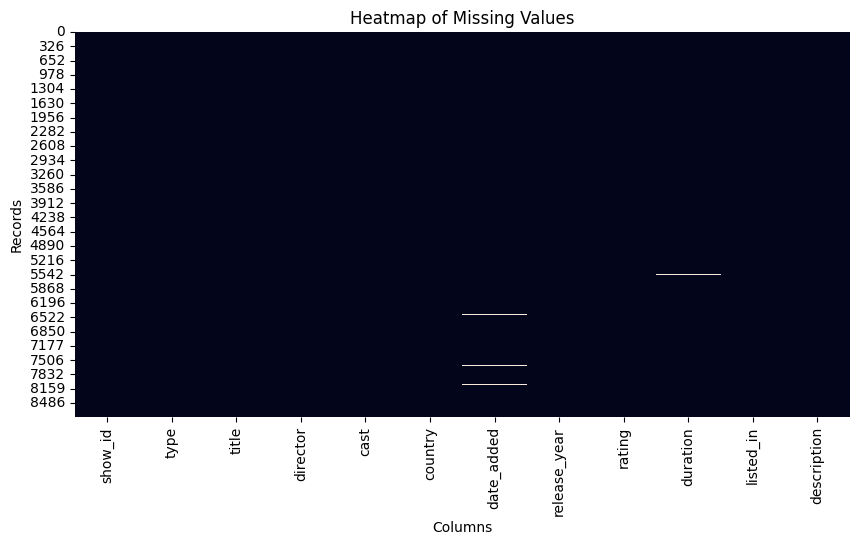

In [ ]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title('Heatmap of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Records')

plt.show()

## **Insights Report**

1. The Bar Chart and Pie Chart show that Movies make up a significantly larger share of Netflix's catalog than TV Shows. This suggests that Netflix prioritizes movie content to attract a broader audience.

2. The country-wise analysis reveals that the United States contributes the highest number of titles on Netflix. This indicates that the platform's content library is heavily influenced by the U.S. entertainment industry.

3. The rating distribution analysis shows that TV-MA is the most common content rating. This suggests that Netflix offers a substantial amount of content targeted toward mature viewers.

4. The Line Chart of release years indicates a sharp increase in the number of titles released after 2015. This reflects Netflix's rapid expansion in content production and acquisition during recent years.

5. The Histogram of release years demonstrates that most content on Netflix is relatively recent, with fewer titles from older decades. This suggests that Netflix focuses primarily on contemporary content that aligns with current viewer preferences.
